In [ ]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = fetch_olivetti_faces()
X = data.images              # (400, 64, 64)
X_flat = X.reshape(400, -1)  # (400, 4096)

In [11]:
mean_face = X_flat.mean(axis=0)   # (4096,)
X_centered = X_flat - mean_face   # (400, 4096)

In [12]:
C = X_centered.T @ X_centered
eigenvalues, eigenvectors = np.linalg.eigh(C)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

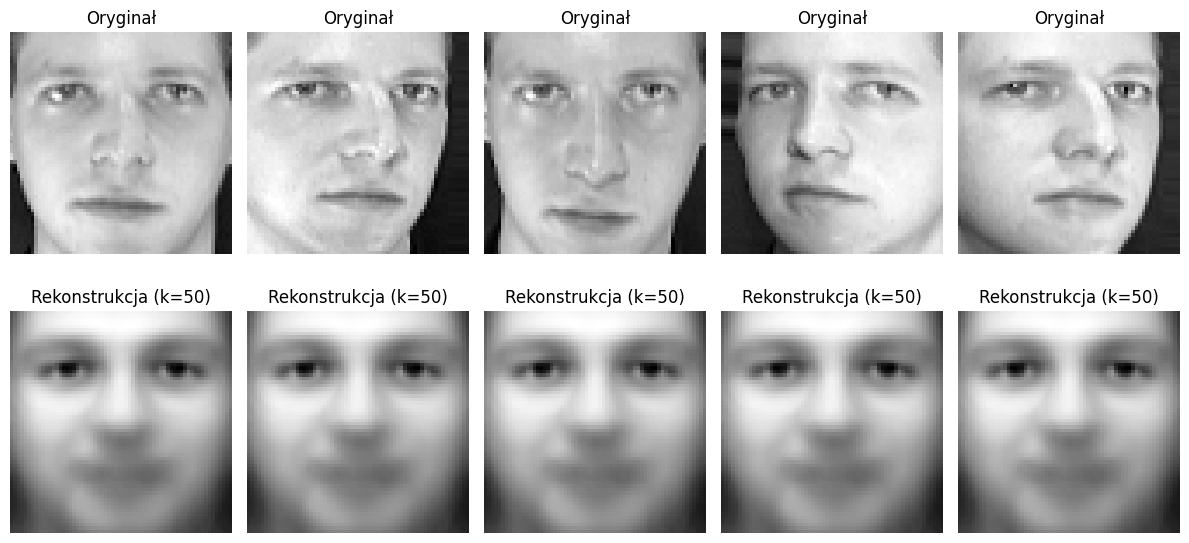

In [20]:
k = 50  # #eigenfaces
W = eigenvectors[:, -k:]  # (4096, 50) – top-k

X_projected = X_centered @ W  # (400, 50)
X_reconstructed = X_projected @ W.T + mean_face


plt.figure(figsize=(12, 6))

for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_flat[i].reshape(64, 64), cmap='gray')
    plt.title("Oryginał")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(X_reconstructed[i].reshape(64, 64), cmap='gray')
    plt.title(f"Rekonstrukcja (k={k})")
    plt.axis('off')

plt.tight_layout()
plt.show()